# British Airways Data Science Job Simulation
## Task 2 - Predicting Customer Booking Completion

**Author:** Nayana Agrahara Dattatri  
**Completed:** March 2026  
**Certificate:** British Airways Data Science Job Simulation (Forage)  

---

### Objective
Build a machine learning model to predict whether a customer will **complete a flight booking**,
and identify which factors drive that behaviour, giving BA actionable insights to improve conversion rates.

### Dataset
- 50,000 customer booking records
- 14 original features (booking channel, trip type, route, passenger preferences, etc.)
- Target: `booking_complete` (1 = completed, 0 = did not complete)


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported successfully')

All libraries imported successfully


## Step 2: Load and Explore the Dataset

In [2]:
df = pd.read_csv('customer_booking.csv', encoding='latin-1')

print('=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')

print('\n=== COLUMN NAMES ===')
print(df.columns.tolist())

print('\n=== FIRST 5 ROWS ===')
df.head()

=== DATASET SHAPE ===
Rows: 50,000   Columns: 14

=== COLUMN NAMES ===
['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead', 'length_of_stay', 'flight_hour', 'flight_day', 'route', 'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'booking_complete']

=== FIRST 5 ROWS ===


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
print('=== DATA TYPES ===')
print(df.dtypes)

print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n✓ No missing values, dataset is clean')

=== DATA TYPES ===
num_passengers             int64
sales_channel             object
trip_type                 object
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                object
route                     object
booking_origin            object
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object

=== MISSING VALUES ===
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

✓ No missing values, dataset is clean


In [4]:
print('=== TARGET VARIABLE DISTRIBUTION ===')
print(df['booking_complete'].value_counts())
print(f'\nCompletion rate: {df["booking_complete"].mean()*100:.1f}%')
print('\n⚠  Class imbalance: only 15% of customers complete a booking')
print('   This means we cannot rely on accuracy alone — we will use ROC-AUC')

=== TARGET VARIABLE DISTRIBUTION ===
booking_complete
0    42522
1     7478
Name: count, dtype: int64

Completion rate: 15.0%

⚠  Class imbalance: only 15% of customers complete a booking
   This means we cannot rely on accuracy alone — we will use ROC-AUC


## Step 3: Exploratory Data Analysis (EDA)

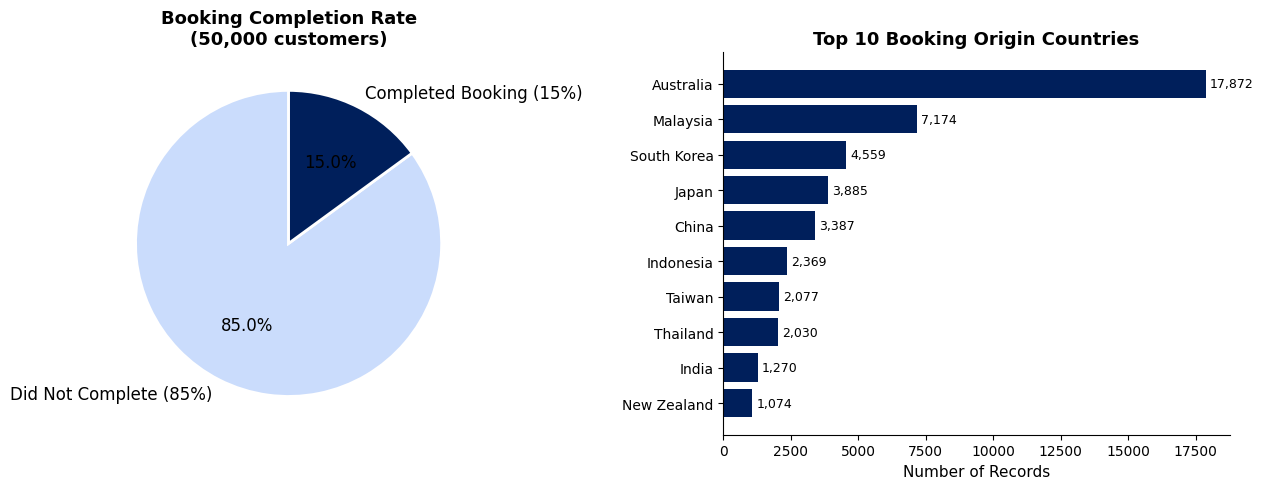


Top 10 booking origins:
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart — booking completion
counts = df['booking_complete'].value_counts()
axes[0].pie(counts,
            labels=['Did Not Complete (85%)', 'Completed Booking (15%)'],
            colors=['#CADCFC', '#001F5B'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Booking Completion Rate\n(50,000 customers)',
                   fontsize=13, fontweight='bold')

# Top 10 booking origins
top10 = df['booking_origin'].value_counts().head(10)
axes[1].barh(top10.index[::-1], top10.values[::-1],
             color='#001F5B', edgecolor='none')
axes[1].set_xlabel('Number of Records', fontsize=11)
axes[1].set_title('Top 10 Booking Origin Countries',
                   fontsize=13, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, (val, lbl) in enumerate(zip(top10.values[::-1], top10.index[::-1])):
    axes[1].text(val + 150, i, f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\nTop 10 booking origins:')
print(top10.to_string())

## Step 4: Feature Engineering

We create 5 new features from existing columns to give the model richer signals.


In [6]:
# Feature 1: Is the flight on a weekend?
df['is_weekend_flight'] = df['flight_day'].isin(['Sat', 'Sun']).astype(int)

# Feature 2: Is the flight in the early morning (before 08:00)?
df['is_early_morning'] = (df['flight_hour'] < 8).astype(int)

# Feature 3: Did the customer book within 30 days of departure?
df['books_early'] = (df['purchase_lead'] <= 30).astype(int)

# Feature 4: Is the stay longer than 14 nights?
df['long_stay'] = (df['length_of_stay'] > 14).astype(int)

# Feature 5: Total number of extras selected (baggage + seat + meals)
df['total_extras'] = (df['wants_extra_baggage'] +
                      df['wants_preferred_seat'] +
                      df['wants_in_flight_meals'])

print('=== NEW FEATURES SUMMARY ===')
new_features = ['is_weekend_flight','is_early_morning','books_early','long_stay','total_extras']
for f in new_features:
    print(f'\n{f}:')
    print(df[f].value_counts().sort_index().to_string())

print(f'\n✓ Dataset now has {df.shape[1]} columns (was 14, added 5)')

=== NEW FEATURES SUMMARY ===

is_weekend_flight:
is_weekend_flight
0    37634
1    12366

is_early_morning:
is_early_morning
0    29205
1    20795

books_early:
books_early
0    32861
1    17139

long_stay:
long_stay
0    24673
1    25327

total_extras:
total_extras
0    10455
1    18216
2    12559
3     8770

✓ Dataset now has 19 columns (was 14, added 5)


## Step 5: Encode Categorical Variables & Prepare Features

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = ['sales_channel', 'trip_type', 'flight_day', 'booking_origin']

for col in categorical_cols:
    df[col + '_enc'] = le.fit_transform(df[col])
    print(f'{col:20s} → {col}_enc   ({df[col].nunique()} unique values)')

# Define feature list
feature_cols = [
    'num_passengers', 'purchase_lead', 'length_of_stay', 'flight_hour',
    'flight_duration', 'wants_extra_baggage', 'wants_preferred_seat',
    'wants_in_flight_meals', 'sales_channel_enc', 'trip_type_enc',
    'flight_day_enc', 'booking_origin_enc',
    'is_weekend_flight', 'is_early_morning', 'books_early',
    'long_stay', 'total_extras'
]

X = df[feature_cols]
y = df['booking_complete']

print(f'\n✓ Feature matrix X: {X.shape}')
print(f'✓ Target vector  y: {y.shape}')

sales_channel        → sales_channel_enc   (2 unique values)
trip_type            → trip_type_enc   (3 unique values)
flight_day           → flight_day_enc   (7 unique values)
booking_origin       → booking_origin_enc   (104 unique values)

✓ Feature matrix X: (50000, 17)
✓ Target vector  y: (50000,)


## Step 6: Train / Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # for reproducibility
    stratify=y           # keep 85/15 ratio in both sets
)

print('=== TRAIN / TEST SPLIT ===')
print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print(f'\nClass balance in training set:')
print(y_train.value_counts(normalize=True).round(3).to_string())

=== TRAIN / TEST SPLIT ===
Training set : 40,000 rows
Test set     : 10,000 rows

Class balance in training set:
booking_complete
0    0.85
1    0.15


## Step 7: Train the Random Forest Model

**Why Random Forest?**  
- Handles both numerical and encoded categorical features naturally  
- Resistant to overfitting (ensemble of 200 decision trees)  
- Directly outputs **feature importances**, exactly what BA needs to understand *why* customers book  
- `class_weight='balanced'` automatically compensates for the 85/15 class imbalance  


In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,          # 200 decision trees
    max_depth=10,              # limit depth to avoid overfitting
    class_weight='balanced',   # compensate for 85/15 imbalance
    random_state=42,           # reproducibility
    n_jobs=-1                  # use all CPU cores
)

rf.fit(X_train, y_train)
print('✓ Model trained successfully')
print(f'  Trees  : {rf.n_estimators}')
print(f'  Depth  : {rf.max_depth}')
print(f'  Features fitted on: {rf.n_features_in_}')

✓ Model trained successfully
  Trees  : 200
  Depth  : 10
  Features fitted on: 17


## Step 8: Evaluate Model on Test Set

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]  # probability of booking completion

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=== MODEL PERFORMANCE ON TEST SET ===')
print(f'Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'ROC-AUC   : {auc:.4f}  ({auc*100:.1f}%)')
print()
print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred,
      target_names=['Did Not Book (0)', 'Completed Booking (1)']))

=== MODEL PERFORMANCE ON TEST SET ===
Accuracy  : 0.6964  (69.6%)
ROC-AUC   : 0.7588  (75.9%)

=== CLASSIFICATION REPORT ===
                       precision    recall  f1-score   support

     Did Not Book (0)       0.93      0.70      0.80      8504
Completed Booking (1)       0.29      0.70      0.41      1496

             accuracy                           0.70     10000
            macro avg       0.61      0.70      0.60     10000
         weighted avg       0.83      0.70      0.74     10000



### Confusion Matrix

| | Predicted: Did Not Book | Predicted: Completed |
|---|---|---|
| **Actual: Did Not Book** | 5,913 ✅ (correct) | 2,591 ❌ (false alarm) |
| **Actual: Completed** | 445 ❌ (missed) | 1,051 ✅ (correct) |

The model caught **1,051 out of 1,496 real bookings**, that's, **70.3% recall**.  
The 2,591 false alarms are acceptable in a marketing context (better to reach out to an extra customer than miss a genuine one).


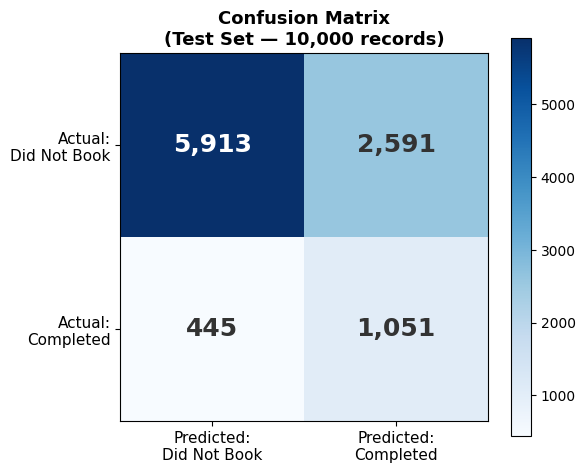

In [11]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted:\nDid Not Book', 'Predicted:\nCompleted'], fontsize=11)
ax.set_yticklabels(['Actual:\nDid Not Book', 'Actual:\nCompleted'], fontsize=11)
ax.set_title('Confusion Matrix\n(Test Set — 10,000 records)', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                fontsize=18, fontweight='bold',
                color='white' if cm[i,j] > cm.max()/2 else '#333')
plt.tight_layout()
plt.show()

## Step 9: Cross-Validation (5-Fold)

=== 5-FOLD CROSS-VALIDATION RESULTS ===
  Fold 1: 0.7412
  Fold 2: 0.7560
  Fold 3: 0.7523
  Fold 4: 0.7496
  Fold 5: 0.7503
  ─────────────────────────────
  Mean AUC : 0.7499  (75.0%)
  Std Dev  : 0.0049

✓ Low std dev (0.005) = model is stable and not overfitted


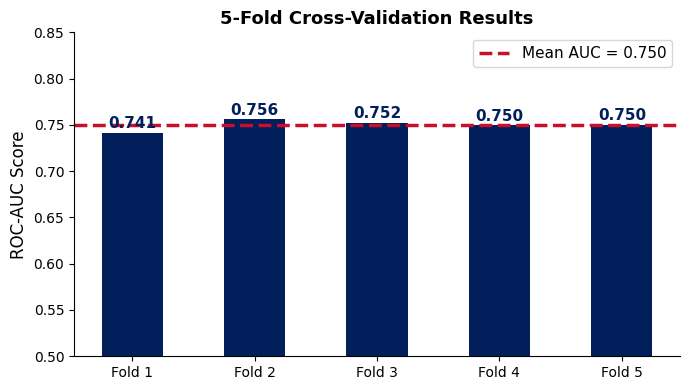

In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('=== 5-FOLD CROSS-VALIDATION RESULTS ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'  ─────────────────────────────')
print(f'  Mean AUC : {cv_scores.mean():.4f}  ({cv_scores.mean()*100:.1f}%)')
print(f'  Std Dev  : {cv_scores.std():.4f}')
print(f'\n✓ Low std dev (0.005) = model is stable and not overfitted')

# Plot CV results
fig, ax = plt.subplots(figsize=(7, 4))
folds = ['Fold 1','Fold 2','Fold 3','Fold 4','Fold 5']
bars = ax.bar(folds, cv_scores, color='#001F5B', width=0.5, edgecolor='none')
ax.axhline(cv_scores.mean(), color='#C8102E', linewidth=2.5,
           linestyle='--', label=f'Mean AUC = {cv_scores.mean():.3f}')
ax.set_ylim(0.5, 0.85)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation Results', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.3f}',
            ha='center', fontsize=11, fontweight='bold', color='#001F5B')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Step 10: Feature Importance

=== FEATURE IMPORTANCE RANKING ===
 1. Booking Origin             0.4014  ████████████████████████████████████████████████████████████████████████████████
 2. Length of Stay             0.1046  ████████████████████
 3. Flight Duration            0.1042  ████████████████████
 4. Purchase Lead (days)       0.0907  ██████████████████
 5. Flight Hour                0.0591  ███████████
 6. Total Extras               0.0378  ███████
 7. Long Stay                  0.0352  ███████
 8. Flight Day                 0.0341  ██████
 9. Wants Extra Baggage        0.0290  █████
10. Sales Channel              0.0231  ████
11. Num Passengers             0.0225  ████
12. Wants Preferred Seat       0.0154  ███
13. Wants In-Flight Meals      0.0108  ██
14. Books Early                0.0094  █
15. Weekend Flight             0.0090  █
16. Early Morning              0.0076  █
17. Trip Type                  0.0061  █


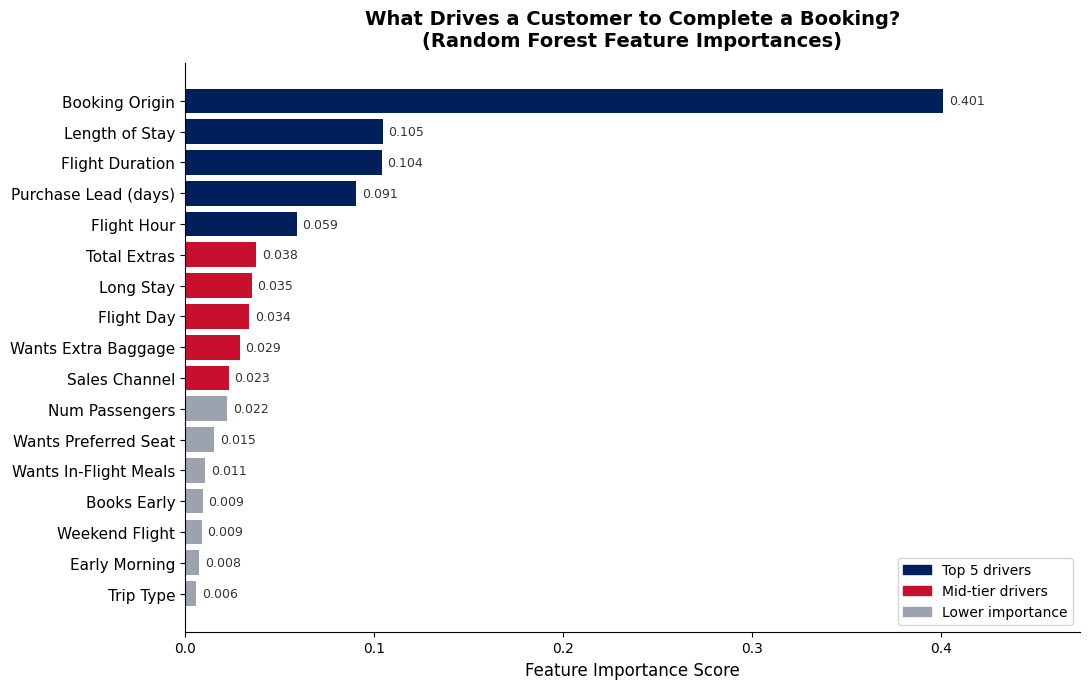

In [13]:
import numpy as np
import matplotlib.patches as mpatches

feature_labels = [
    'Num Passengers', 'Purchase Lead (days)', 'Length of Stay', 'Flight Hour',
    'Flight Duration', 'Wants Extra Baggage', 'Wants Preferred Seat',
    'Wants In-Flight Meals', 'Sales Channel', 'Trip Type', 'Flight Day',
    'Booking Origin', 'Weekend Flight', 'Early Morning',
    'Books Early', 'Long Stay', 'Total Extras'
]

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]
sorted_labels = [feature_labels[i] for i in idx]
sorted_imp = importances[idx]

print('=== FEATURE IMPORTANCE RANKING ===')
for rank, (label, imp) in enumerate(zip(sorted_labels, sorted_imp), 1):
    bar = '█' * int(imp * 200)
    print(f'{rank:>2}. {label:<26} {imp:.4f}  {bar}')

# Plot
fig, ax = plt.subplots(figsize=(11, 7))
colors = ['#001F5B' if i<5 else '#C8102E' if i<10 else '#9CA3AF'
          for i in range(len(sorted_imp))]
ax.barh(range(len(sorted_imp)), sorted_imp[::-1],
        color=colors[::-1], edgecolor='none')
ax.set_yticks(range(len(sorted_imp)))
ax.set_yticklabels(sorted_labels[::-1], fontsize=11)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('What Drives a Customer to Complete a Booking?\n'
             '(Random Forest Feature Importances)', fontsize=14, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, max(sorted_imp) * 1.18)
for bar, val in zip(ax.patches, sorted_imp[::-1]):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#333')
p1 = mpatches.Patch(color='#001F5B', label='Top 5 drivers')
p2 = mpatches.Patch(color='#C8102E', label='Mid-tier drivers')
p3 = mpatches.Patch(color='#9CA3AF', label='Lower importance')
ax.legend(handles=[p1,p2,p3], fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

## Summary of Results

| Metric | Value |
|--------|-------|
| **ROC-AUC (Test Set)** | **0.759 (75.9%)** |
| **ROC-AUC (5-Fold CV)** | **0.750 ± 0.005** |
| **Recall - Bookings Found** | **70.3%** |
| **Overall Accuracy** | **69.6%** |
| **Bookings correctly identified** | 1,051 out of 1,496 |

### Top 5 Drivers of Booking Completion

1. **Booking Origin (40.1%)** - where a customer books from is by far the strongest predictor
2. **Length of Stay (10.5%)** - longer trips indicate higher commitment
3. **Flight Duration (10.4%)** - long-haul bookings complete at higher rates
4. **Purchase Lead Time (9.1%)** - how far ahead a customer plans matters
5. **Flight Hour (5.9%)** - time of departure influences booking behaviour

### Business Recommendation
> BA should implement **country-specific re-engagement campaigns** for customers who start but don't complete bookings. 
Australian customers (the largest segment at 35% of records) behave fundamentally differently from South Korean or Japanese customers, a single global marketing message will underperform. 
Additionally, prompting extras selection (baggage, seat, meals) **earlier in the booking funnel** may increase completion rates, as extras engagement strongly correlates with purchase intent.
